# Coffee Quality Prediction Model
## Ethiopian Coffee Quality Predictor — model 1

This notebook builds an XGBoost regression model to predict coffee quality
scores from origin, processing, and sensory features.
It also includes K-means clustering for flavor families and SHAP
explainability.

## CELL 1 — Imports

Importing all required libraries for data processing, modeling,
visualization, and model export.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import kagglehub, os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import shap
from sklearn.cluster import KMeans

## CELL 2 — Load dataset

Load the CQI Coffee Quality dataset using kagglehub.
The target column is 'Total Cup Points' (0-100).

In [5]:
path = kagglehub.dataset_download("fatihb/coffee-quality-data-cqi")

csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset loaded: 207 rows, 41 columns
Columns: ['Unnamed: 0', 'ID', 'Country of Origin', 'Farm Name', 'Lot Number', 'Mill', 'ICO Number', 'Company', 'Altitude', 'Region', 'Producer', 'Number of Bags', 'Bag Weight', 'In-Country Partner', 'Harvest Year', 'Grading Date', 'Owner', 'Variety', 'Status', 'Processing Method', 'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity', 'Clean Cup', 'Sweetness', 'Overall', 'Defects', 'Total Cup Points', 'Moisture Percentage', 'Category One Defects', 'Quakers', 'Color', 'Category Two Defects', 'Expiration', 'Certification Body', 'Certification Address', 'Certification Contact']


,Unnamed: 0,ID,Country of Origin,Farm Name,Lot Number,Mill,ICO Number,Company,Altitude,Region,...,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Color,Category Two Defects,Expiration,Certification Body,Certification Address,Certification Contact
0,0,0,Colombia,Finca El Paraiso,CQU2022015,Finca El Paraiso,NaN,Coffee Quality Union,1700-1930,"Piendamo,Cauca",...,89.33,11.8,0,0,green,3,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
1,1,1,Taiwan,Royal Bean Geisha Estate,"The 2022 Pacific Rim Coffee Summit,T037",Royal Bean Geisha Estate,NaN,Taiwan Coffee Laboratory,1200,Chiayi,...,87.58,10.5,0,0,blue-green,0,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
2,2,2,Laos,OKLAO coffee farms,"The 2022 Pacific Rim Coffee Summit,LA01",oklao coffee processing plant,NaN,Taiwan Coffee Laboratory,1300,Laos Borofen Plateau,...,87.42,10.4,0,0,yellowish,2,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
3,3,3,Costa Rica,La Cumbre,CQU2022017,La Montana Tarrazu MIll,NaN,Coffee Quality Union,1900,"Los Santos,Tarrazu",...,87.17,11.8,0,0,green,0,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
4,4,4,Colombia,Finca Santuario,CQU2023002,Finca Santuario,NaN,Coffee Quality Union,1850-2100,"Popayan,Cauca",...,87.08,11.6,0,2,yellow-green,2,"March 5th, 2024",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901


## CELL 3 — Inspect data

Check dimensions, summary statistics, and missing values.

In [6]:
print(f"Shape: {df.shape}")
print("\nMissing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape: (207, 41)

Missing values per column:
Farm Name              2
Lot Number             1
Mill                   3
ICO Number           132
Altitude               1
Region                 2
Producer               1
Variety                6
Processing Method      5
dtype: int64


## CELL 4 — Clean data

Drop rows where the target is missing and impute Altitude using
the median per country.

In [7]:
# Drop rows where target variable is missing
target_col = 'Total Cup Points'
df.dropna(subset=[target_col], inplace=True)
print(f"Rows after dropping missing targets: {len(df)}")

# Clean Altitude column - handle ranges like '900-1000'
altitude_col = None
for col in ['Altitude', 'altitude_mean_meters', 'altitude', 'Altitude_mean']:
    if col in df.columns:
        altitude_col = col
        break

if altitude_col:
    print(f"Using altitude column: {altitude_col}")
    # Convert to string, then extract numeric values from ranges
    df[altitude_col] = df[altitude_col].astype(str)
    # For ranges like '900-1000', take the average; for single values, keep as is
    def parse_altitude(val):
        if val == 'nan' or val == 'None':
            return np.nan
        if '-' in val:
            parts = val.split('-')
            try:
                return (float(parts[0]) + float(parts[1])) / 2
            except:
                return np.nan
        try:
            return float(val)
        except:
            return np.nan
    
    # Apply parsing and explicitly convert to numeric
    df['Altitude'] = pd.to_numeric(df[altitude_col].apply(parse_altitude), errors='coerce')
    # Impute missing with median per country
    df['Altitude'] = df.groupby('Country of Origin')['Altitude'].transform(lambda x: x.fillna(x.median()))
    # If still any NaN (e.g., entire country has no altitude data), fill with global median
    df['Altitude'].fillna(df['Altitude'].median(), inplace=True)
    print(f"Altitude cleaned. Range: {df['Altitude'].min():.0f}m - {df['Altitude'].max():.0f}m")
else:
    print("WARNING: No altitude column found. Using default value 1500m.")
    df['Altitude'] = 1500

region_lookup = df[['Country of Origin', 'Region']].copy()
df.head()

Rows after dropping missing targets: 207
Using altitude column: Altitude
Altitude cleaned. Range: 139m - 5400m


/tmp/ipykernel_105846/1451238000.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Altitude'].fillna(df['Altitude'].median(), inplace=True)


,Unnamed: 0,ID,Country of Origin,Farm Name,Lot Number,Mill,ICO Number,Company,Altitude,Region,...,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Color,Category Two Defects,Expiration,Certification Body,Certification Address,Certification Contact
0,0,0,Colombia,Finca El Paraiso,CQU2022015,Finca El Paraiso,NaN,Coffee Quality Union,1815.0,"Piendamo,Cauca",...,89.33,11.8,0,0,green,3,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
1,1,1,Taiwan,Royal Bean Geisha Estate,"The 2022 Pacific Rim Coffee Summit,T037",Royal Bean Geisha Estate,NaN,Taiwan Coffee Laboratory,1200.0,Chiayi,...,87.58,10.5,0,0,blue-green,0,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
2,2,2,Laos,OKLAO coffee farms,"The 2022 Pacific Rim Coffee Summit,LA01",oklao coffee processing plant,NaN,Taiwan Coffee Laboratory,1300.0,Laos Borofen Plateau,...,87.42,10.4,0,0,yellowish,2,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
3,3,3,Costa Rica,La Cumbre,CQU2022017,La Montana Tarrazu MIll,NaN,Coffee Quality Union,1900.0,"Los Santos,Tarrazu",...,87.17,11.8,0,0,green,0,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
4,4,4,Colombia,Finca Santuario,CQU2023002,Finca Santuario,NaN,Coffee Quality Union,1975.0,"Popayan,Cauca",...,87.08,11.6,0,2,yellow-green,2,"March 5th, 2024",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901


## CELL 5 — EDA: distribution of quality scores

Histogram of Total Cup Points to understand the target distribution.

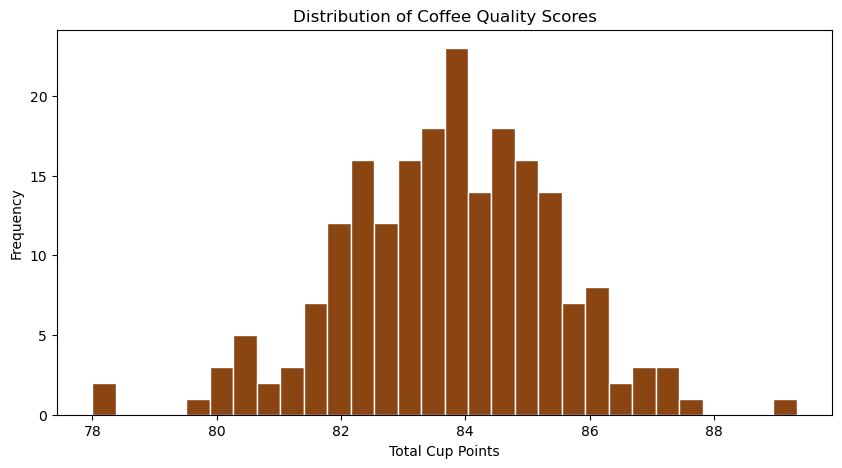

In [8]:
os.makedirs('outputs/charts', exist_ok=True)
plt.figure(figsize=(10, 5))
plt.hist(df[target_col], bins=30, color='saddlebrown', edgecolor='white')
plt.title('Distribution of Coffee Quality Scores')
plt.xlabel('Total Cup Points')
plt.ylabel('Frequency')
plt.savefig('outputs/charts/score_distribution.png')
plt.show()

## CELL 6 — EDA: correlation heatmap

Correlation heatmap of sensory features to see which ones drive quality.

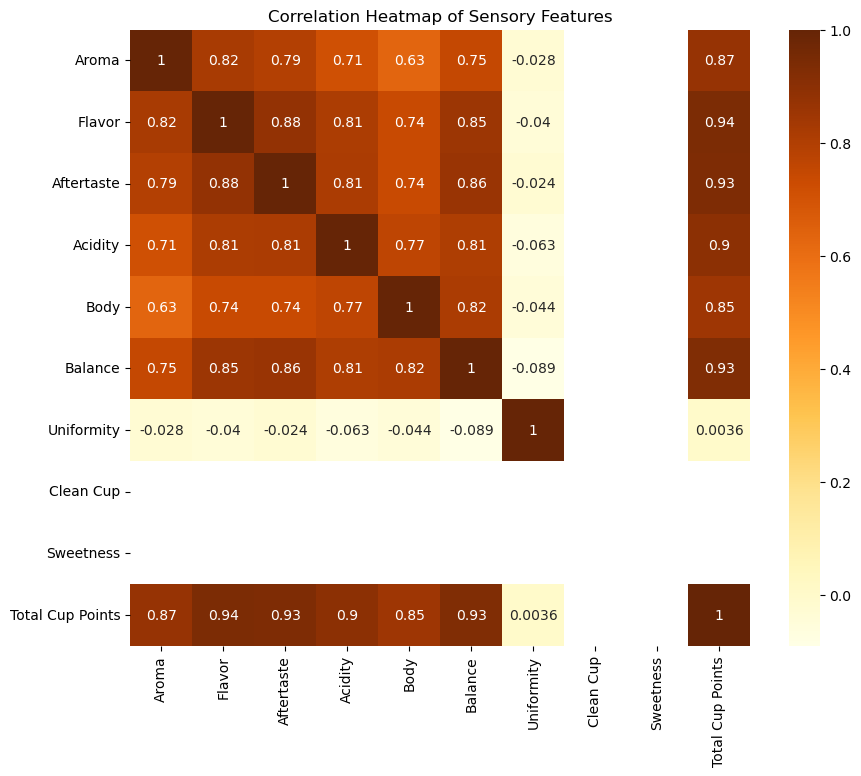

In [9]:
sensory_cols = ['Aroma','Flavor','Aftertaste','Acidity',
                'Body','Balance','Uniformity','Clean Cup',
                'Sweetness', target_col]
plt.figure(figsize=(10, 8))
sns.heatmap(df[sensory_cols].corr(), annot=True, cmap='YlOrBr')
plt.title('Correlation Heatmap of Sensory Features')
plt.savefig('outputs/charts/correlation_heatmap.png')
plt.show()

## CELL 7 — EDA: score by country (highlight Ethiopia)

Boxplot of quality scores across the top 15 producing countries.

/tmp/ipykernel_105846/3469514412.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df[country_col].isin(country_order)],


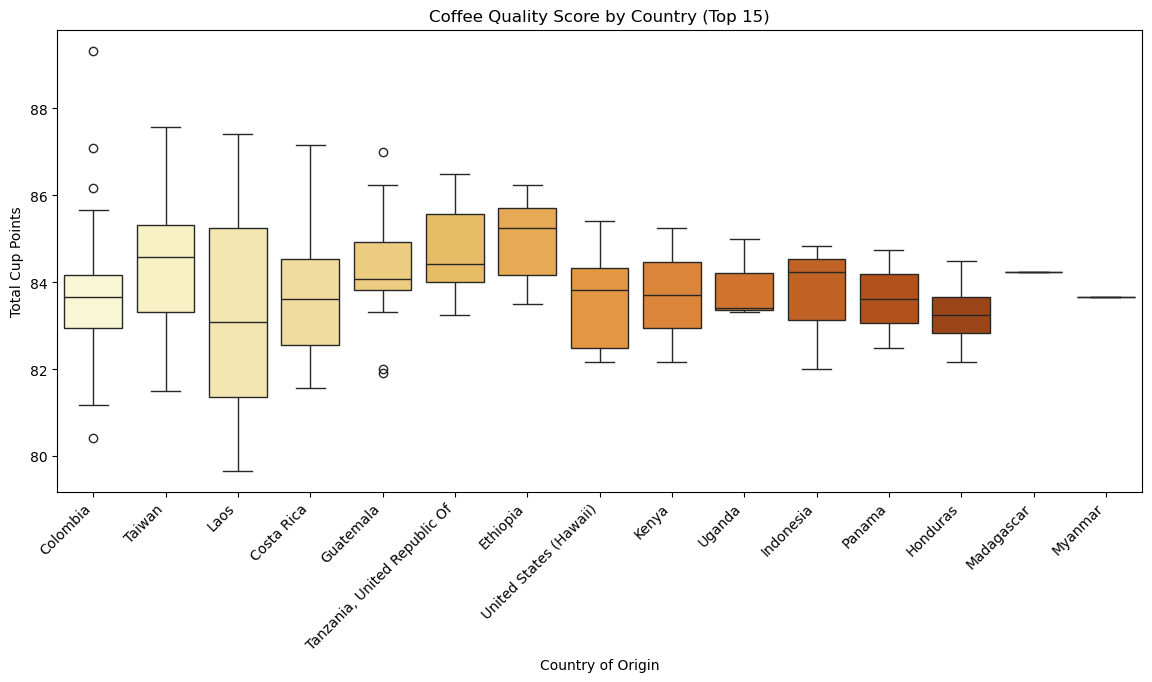

In [10]:
plt.figure(figsize=(14, 6))
country_col = 'Country of Origin'
country_order = df.groupby(country_col)[target_col].median().sort_values(ascending=False).index[:15]
sns.boxplot(data=df[df[country_col].isin(country_order)],
            x=country_col, y=target_col,
            palette='YlOrBr')
plt.xticks(rotation=45, ha='right')
plt.title('Coffee Quality Score by Country (Top 15)')
plt.savefig('outputs/charts/score_by_country.png')
plt.show()

## CELL 8 — EDA: score by processing method

Boxplot of quality scores by processing method.

/tmp/ipykernel_105846/1967933372.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Processing Method', y=target_col,


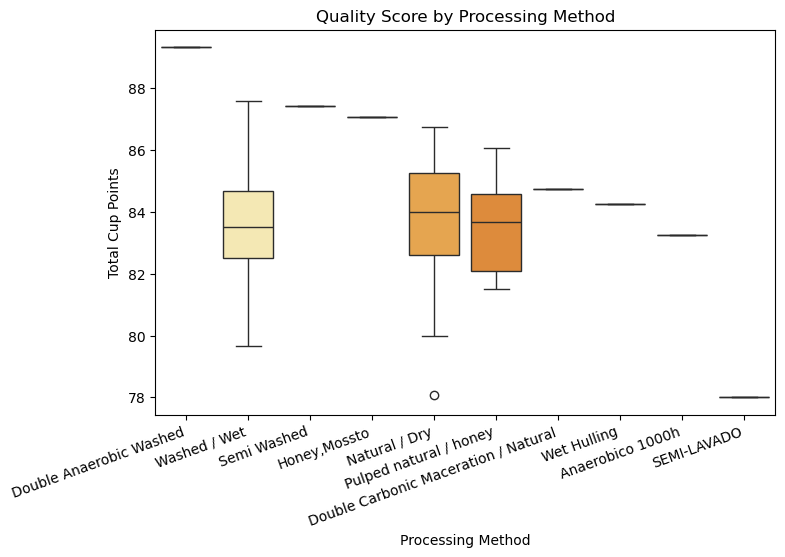

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Processing Method', y=target_col,
            palette='YlOrBr')
plt.xticks(rotation=20, ha='right')
plt.title('Quality Score by Processing Method')
plt.savefig('outputs/charts/score_by_processing.png')
plt.show()

## CELL 9 — Encode categorical columns

One-hot encode Processing.Method and Country.of.Origin.
drop_first=True avoids multicollinearity.

In [12]:
# One-hot encoding for Processing.Method and Country.of.Origin
processing_dummies = pd.get_dummies(df['Processing Method'], drop_first=True)
country_dummies = pd.get_dummies(df['Country of Origin'], drop_first=True)
df = pd.concat([df, processing_dummies, country_dummies], axis=1)
df.drop(['Processing Method', 'Country of Origin'], axis=1, inplace=True)
df.head()

,Unnamed: 0,ID,Farm Name,Lot Number,Mill,ICO Number,Company,Altitude,Region,Producer,...,Myanmar,Nicaragua,Panama,Peru,Taiwan,"Tanzania, United Republic Of",Thailand,Uganda,United States (Hawaii),Vietnam
0,0,0,Finca El Paraiso,CQU2022015,Finca El Paraiso,NaN,Coffee Quality Union,1815.0,"Piendamo,Cauca",Diego Samuel Bermudez,...,False,False,False,False,False,False,False,False,False,False
1,1,1,Royal Bean Geisha Estate,"The 2022 Pacific Rim Coffee Summit,T037",Royal Bean Geisha Estate,NaN,Taiwan Coffee Laboratory,1200.0,Chiayi,曾福森,...,False,False,False,False,True,False,False,False,False,False
2,2,2,OKLAO coffee farms,"The 2022 Pacific Rim Coffee Summit,LA01",oklao coffee processing plant,NaN,Taiwan Coffee Laboratory,1300.0,Laos Borofen Plateau,WU TAO CHI,...,False,False,False,False,False,False,False,False,False,False
3,3,3,La Cumbre,CQU2022017,La Montana Tarrazu MIll,NaN,Coffee Quality Union,1900.0,"Los Santos,Tarrazu",Santa Maria de Dota,...,False,False,False,False,False,False,False,False,False,False
4,4,4,Finca Santuario,CQU2023002,Finca Santuario,NaN,Coffee Quality Union,1975.0,"Popayan,Cauca",Camilo Merizalde,...,False,False,False,False,False,False,False,False,False,False


## CELL 10 — Separate independent and dependent variables

Build X (features) and y (target) explicitly.

In [13]:
wanted = ['Altitude', 'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body',
          'Balance', 'Uniformity', 'Clean Cup', 'Sweetness',
          'Moisture Percentage', 'Category One Defects', 'Category Two Defects']

feature_cols = [c for c in df.columns 
                if c != target_col 
                and df[c].dtype in ['float64','int64','uint8']
                and not c.startswith('Unnamed')
                and c not in ['ID', 'Overall', 'Defects', 'Quakers', 'Number of Bags']]

print("Feature columns:", feature_cols)

X = df[feature_cols].values
y = df[target_col].values
print("X shape:", X.shape)
print("y shape:", y.shape)

Feature columns: ['Altitude', 'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity', 'Clean Cup', 'Sweetness', 'Moisture Percentage', 'Category One Defects', 'Category Two Defects']
X shape: (207, 13)
y shape: (207,)


## CELL 11 — Train/test split

75/25 split with a fixed random_state for reproducibility.

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)

X_train shape: (155, 13)
X_test  shape: (52, 13)


## CELL 12 — Scale features

StandardScaler fitted on training data only, then applied to test.

In [15]:
from sklearn.preprocessing import StandardScaler
st = StandardScaler()
X_train = st.fit_transform(X_train)
X_test = st.transform(X_test)
print("Features scaled successfully")
print(X_train[:3])

Features scaled successfully
[[-1.06174939  0.94904084  0.57252499  1.37156709  0.46493414  0.07232813
   1.34730945  0.10850369  0.          0.         -1.40218931 -0.21979349
  -0.76246912]
 [ 0.43502201  1.55912198  0.86205638  1.08054327  0.81047657  2.24497557
   0.37236564  0.10850369  0.          0.         -0.72056951 -0.21979349
  -0.76246912]
 [ 0.15390251 -0.23523432  0.57252499  1.08054327  0.46493414  0.41995172
   0.68434766  0.10850369  0.          0.         -0.33107248 -0.21979349
  -0.76246912]]


## CELL 13 — Baseline: Linear Regression

Train a simple Linear Regression as a performance benchmark.

In [16]:
baseline = LinearRegression()
baseline.fit(X_train, y_train)

y_pred_train = baseline.predict(X_train)
y_pred_test = baseline.predict(X_test)

print("=== Baseline: Linear Regression ===")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.3f}")
print(f"Test  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.3f}")
print(f"Train R2:   {r2_score(y_train, y_pred_train):.3f}")
print(f"Test  R2:   {r2_score(y_test, y_pred_test):.3f}")

=== Baseline: Linear Regression ===
Train RMSE: 0.109
Test  RMSE: 0.128
Train R2:   0.996
Test  R2:   0.994


## CELL 14 — K-fold cross-validation on baseline

Validate the baseline with 5-fold cross-validation.

In [17]:
from sklearn.model_selection import KFold, cross_val_score
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(baseline, X, y, cv=kf, scoring='r2')
print(f'Cross-Validation Scores: {cv_scores}')
print(f'Average Cross-Validation Score: {cv_scores.mean():.2f}')

Cross-Validation Scores: [0.99263041 0.99574653 0.97930739 0.99728034 0.99716386]
Average Cross-Validation Score: 0.99


## CELL 15 — Main model: XGBoost with GridSearchCV

XGBoost builds many decision trees sequentially, each correcting
the errors of the previous. GridSearchCV finds the best parameters.

In [18]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2]
}
xgb = XGBRegressor(random_state=42)
grid_search = GridSearchCV(xgb, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}


## CELL 16 — Evaluate XGBoost vs baseline

Compare train/test RMSE and R2 for the tuned XGBoost model.

In [19]:
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

print("=== XGBoost (best params) ===")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.3f}")
print(f"Test  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.3f}")
print(f"Train R2:   {r2_score(y_train, y_pred_train):.3f}")
print(f"Test  R2:   {r2_score(y_test, y_pred_test):.3f}")

=== XGBoost (best params) ===
Train RMSE: 0.065
Test  RMSE: 0.341
Train R2:   0.999
Test  R2:   0.960


## CELL 17 — Cross-validation on XGBoost

5-fold cross-validation to confirm generalization.

In [20]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X, y, cv=kf, scoring='r2')
print(f'Cross-Validation Scores: {cv_scores}')
print(f'Average Cross-Validation Score: {cv_scores.mean():.2f}')

Cross-Validation Scores: [0.94823044 0.97461237 0.94634547 0.97853272 0.9421097 ]
Average Cross-Validation Score: 0.96


## CELL 18 — SHAP explainability

SHAP explains WHY the model made each prediction.
Each feature gets a value: positive = pushed score up, negative = down.

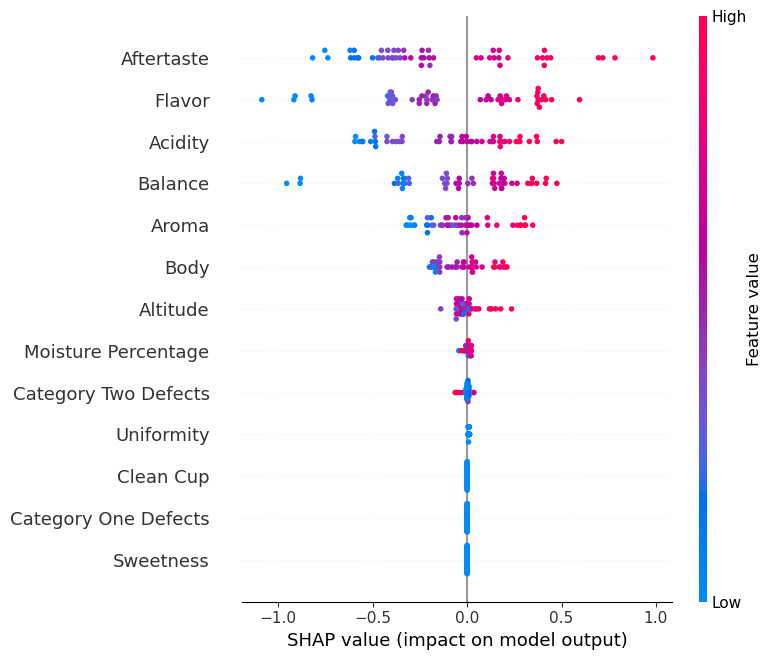

['Altitude', 'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity', 'Clean Cup', 'Sweetness', 'Moisture Percentage', 'Category One Defects', 'Category Two Defects']


In [21]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)
plt.savefig('outputs/charts/shap_summary.png', bbox_inches='tight')
plt.show()
print(feature_cols)

## CELL 19 — Predict on new data (standalone example)

This is exactly what FastAPI will do at runtime.

In [22]:
new_coffee_dict = {col: 0 for col in feature_cols}

new_coffee_dict.update({
    'Altitude': 1900,
    'Aroma': 8.5,
    'Flavor': 8.3,
    'Aftertaste': 8.0,
    'Acidity': 8.2,
    'Body': 8.1,
    'Balance': 8.0,
    'Uniformity': 10.0,
    'Clean Cup': 10.0,
    'Sweetness': 10.0,
    'Moisture Percentage': 0.05,
    'Category One Defects': 0,
    'Category Two Defects': 0,
})

new_coffee_df = pd.DataFrame([new_coffee_dict])[feature_cols]
new_scaled = st.transform(new_coffee_df)
prediction = best_model.predict(new_scaled)
shap_new = explainer.shap_values(new_scaled)

print(f'Predicted Quality Score: {prediction[0]:.1f}')
top_features = sorted(zip(feature_cols, shap_new[0]), key=lambda x: abs(x[1]), reverse=True)[:4]
print(f'Top SHAP features: {top_features}')

Predicted Quality Score: 87.5
Top SHAP features: [('Aroma', np.float32(0.8717834)), ('Aftertaste', np.float32(0.8402574)), ('Flavor', np.float32(0.62295455)), ('Acidity', np.float32(0.58790165))]


/home/natnael/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


## CELL 20 — K-means flavor clustering (Feature 1)

K-means clustering to discover natural "flavor families".
We run on sensory features only (not origin/altitude).

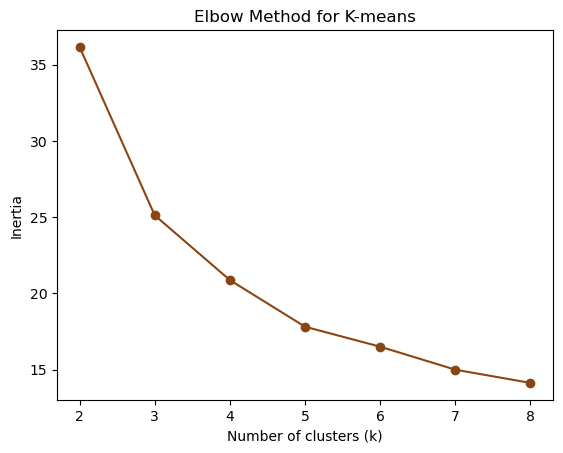

In [23]:
sensory_features = ['Aroma','Flavor','Acidity','Body','Balance']
X_sensory = df[sensory_features].values

inertias = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=12, random_state=42)
    km.fit(X_sensory)
    inertias.append(km.inertia_)

plt.plot(range(2, 9), inertias, marker='o', color='saddlebrown')
plt.title('Elbow Method for K-means')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.savefig('outputs/charts/kmeans_elbow.png')
plt.show()

## CELL 21 — Fit final K-means and label clusters

Fit final K-means with chosen k (e.g. 4) and assign human-readable names.

Cluster centers:
 [[8.1735     8.192      8.067      7.98       8.047     ]
 [7.63731707 7.67121951 7.62719512 7.59536585 7.58585366]
 [7.89117647 7.91661765 7.85088235 7.76838235 7.79411765]
 [7.34945946 7.35       7.33135135 7.32432432 7.27945946]]
                  Aroma    Flavor   Acidity      Body   Balance
FlavorCluster                                                  
0              8.173500  8.192000  8.067000  7.980000  8.047000
1              7.637317  7.671220  7.627195  7.595366  7.585854
2              7.891176  7.916618  7.850882  7.768382  7.794118
3              7.349459  7.350000  7.331351  7.324324  7.279459


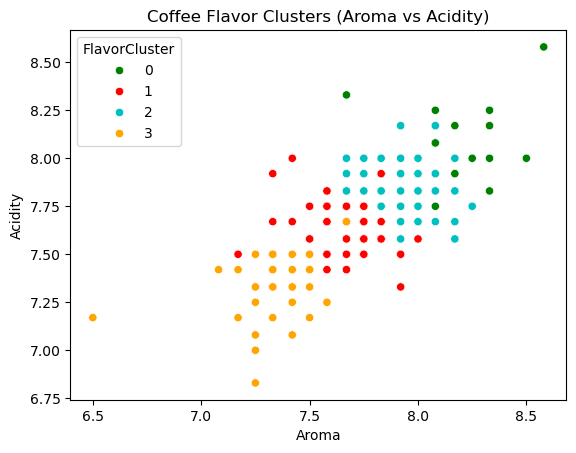

{0: {'name': 'Bright & Floral', 'description': 'High acidity and aroma'}, 1: {'name': 'Earthy & Full-bodied', 'description': 'High body, lower acidity'}, 2: {'name': 'Balanced & Sweet', 'description': 'High balance and sweetness'}, 3: {'name': 'Mild & Neutral', 'description': 'Lower scores across all sensory features'}}


In [24]:
kmeans = KMeans(n_clusters=4, n_init=12, random_state=42)
labels = kmeans.fit_predict(X_sensory)
print("Cluster centers:\n", kmeans.cluster_centers_)

df['FlavorCluster'] = labels
print(df.groupby('FlavorCluster')[sensory_features].mean())

sns.scatterplot(x=df['Aroma'], y=df['Acidity'], hue=df['FlavorCluster'], palette=['g','r','c','orange'])
plt.title('Coffee Flavor Clusters (Aroma vs Acidity)')
plt.savefig('outputs/charts/kmeans_clusters.png')
plt.show()

cluster_label_map = {
    0: {"name": "Bright & Floral", "description": "High acidity and aroma"},
    1: {"name": "Earthy & Full-bodied", "description": "High body, lower acidity"},
    2: {"name": "Balanced & Sweet", "description": "High balance and sweetness"},
    3: {"name": "Mild & Neutral", "description": "Lower scores across all sensory features"}
}
print(cluster_label_map)

## CELL 22 — Counterfactual suggestions (Feature 2)

For coffees scoring below 80, suggest the smallest change to
push them into specialty grade (score >= 80).

In [25]:

def suggest_improvement(row_scaled, shap_vals, current_score, feature_cols, model, scaler):
    if current_score >= 80:
        return None

    # Find top 2 features that hurt the score most (most negative SHAP)
    ranked = sorted(zip(feature_cols, shap_vals), key=lambda x: x[1])
    suggestions = []

    for feat, _ in ranked[:2]:
        if 'Altitude' in feat:
            for delta in [100, 200, 300]:
                trial = row_scaled.copy()
                idx = feature_cols.index(feat)
                trial[0][idx] += delta / scaler.scale_[idx]
                new_score = model.predict(trial)[0]
                if new_score >= 80:
                    suggestions.append(f"Increase altitude by {delta}m -> predicted score: {new_score:.1f}")
                    break

    return suggestions[0] if suggestions else 'Consider improving processing method or growing conditions.'

below_80 = X_test[y_test < 80]
if len(below_80) > 0:
    sample = below_80[0:1]
    score = best_model.predict(sample)[0]
    shap_sample = explainer.shap_values(sample)[0]
    suggestion = suggest_improvement(sample, shap_sample, score, feature_cols, best_model, st)
    print(f"Current score: {score:.1f}")
    print(f"Suggestion: {suggestion}")

Current score: 80.0
Suggestion: Consider improving processing method or growing conditions.


## CELL 23 — Ethiopian region aggregation (Feature 3)

Reload original df before encoding to keep Region column,
then predict scores for Ethiopian coffees and aggregate by region.

In [26]:
import json

ethiopia_mask = region_lookup['Country of Origin'] == 'Ethiopia'
df_ethiopia = df[ethiopia_mask].copy()


# Predict using the same feature columns and scaler from training
X_eth = df_ethiopia[feature_cols].values
X_eth_scaled = st.transform(X_eth)
df_ethiopia['PredictedScore'] = best_model.predict(X_eth_scaled)

regions_summary = df_ethiopia.groupby('Region').agg(
    avgScore=('PredictedScore', 'mean'),
    sampleCount=('PredictedScore', 'count')
).reset_index()
print(regions_summary)

regions_json = regions_summary.to_dict(orient='records')
with open('outputs/models/regions.json', 'w') as f:
    json.dump(regions_json, f, indent=2)
print("Saved regions.json")

                     Region   avgScore  sampleCount
0               Addis Ababa  84.298965            1
1                  Ethiopia  84.433365            1
2  Gedeb,Yirgacheffe,Sidamo  86.106911            1
3                      Guji  86.284775            2
4                    OROMIA  84.400955            2
5                    Oromia  85.369125            1
6                    Sidama  83.978470            2
7    Southern Ethiopia Guji  85.341743            1
Saved regions.json


## CELL 24  —  Bar Chart of predicted Score by region

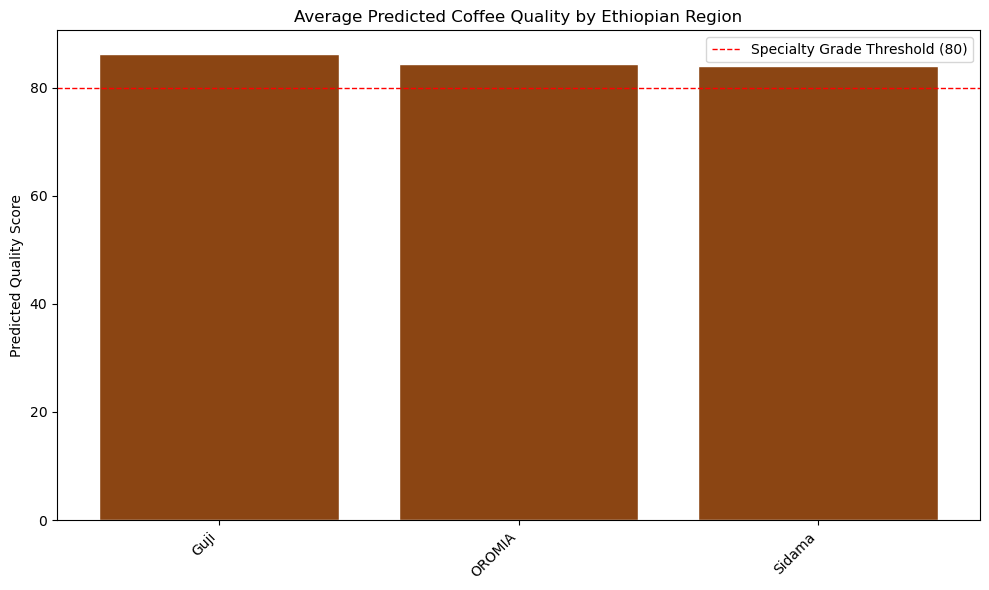

In [27]:
plt.figure(figsize=(10, 6))
plot_df = regions_summary[regions_summary['sampleCount'] >= 2]  # filter tiny-sample regions for readability
bars = plt.bar(plot_df['Region'], plot_df['avgScore'], color='saddlebrown', edgecolor='white')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Predicted Quality Score')
plt.title('Average Predicted Coffee Quality by Ethiopian Region')
plt.axhline(y=80, color='red', linestyle='--', linewidth=1, label='Specialty Grade Threshold (80)')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/charts/ethiopia_region_scores.png', dpi=120)
plt.show()


## CELL 25 — Predicted vs Actual of ethiopia predictions

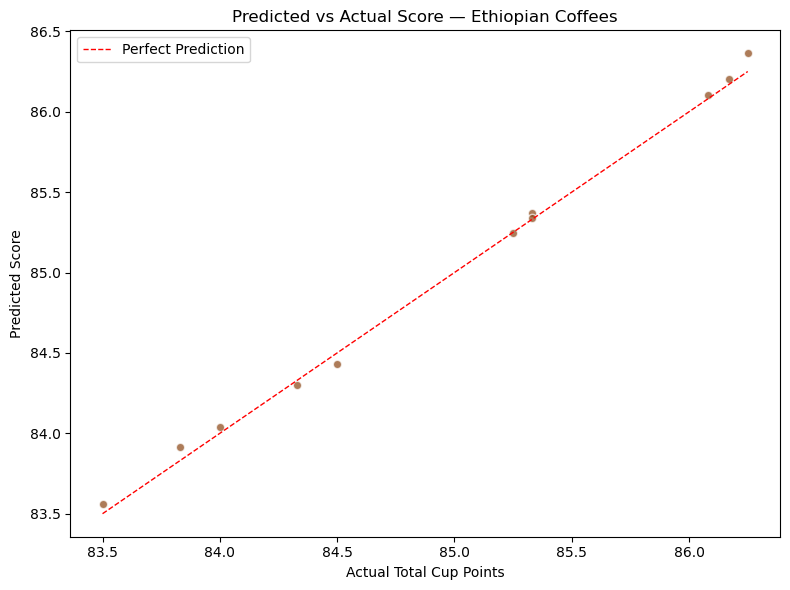

In [28]:
plt.figure(figsize=(8, 6))
plt.scatter(df_ethiopia['Total Cup Points'], df_ethiopia['PredictedScore'],
            color='saddlebrown', alpha=0.7, edgecolor='white')
min_v, max_v = df_ethiopia['Total Cup Points'].min(), df_ethiopia['Total Cup Points'].max()
plt.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1, label='Perfect Prediction')
plt.xlabel('Actual Total Cup Points')
plt.ylabel('Predicted Score')
plt.title('Predicted vs Actual Score \u2014 Ethiopian Coffees')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/charts/ethiopia_predicted_vs_actual.png', dpi=120)
plt.show()

##  CELL 26 — Sample count pre region

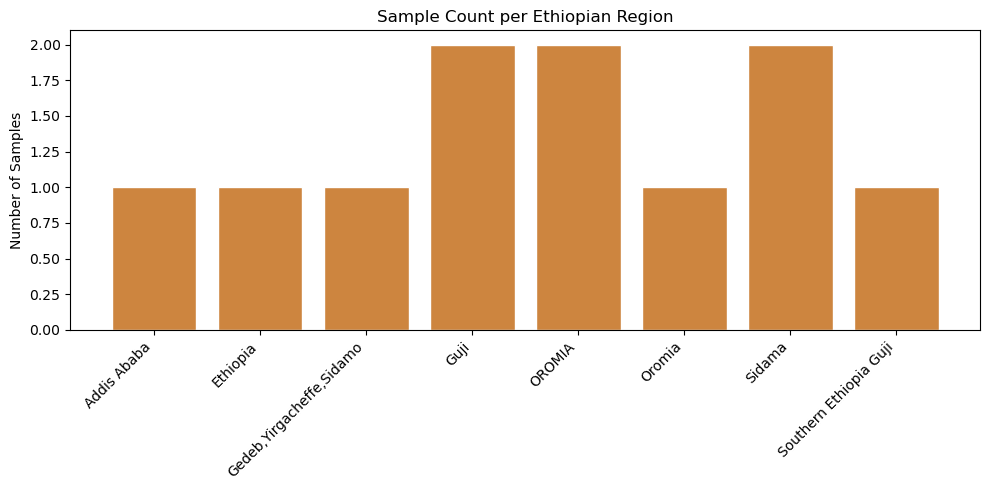


Done. Charts saved to outputs/charts/:
 - ethiopia_region_scores.png
 - ethiopia_predicted_vs_actual.png
 - ethiopia_region_sample_counts.png


In [29]:
plt.figure(figsize=(10, 5))
plt.bar(regions_summary['Region'], regions_summary['sampleCount'], color='peru', edgecolor='white')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Samples')
plt.title('Sample Count per Ethiopian Region')
plt.tight_layout()
plt.savefig('outputs/charts/ethiopia_region_sample_counts.png', dpi=120)
plt.show()
 
print("\nDone. Charts saved to outputs/charts/:")
print(" - ethiopia_region_scores.png")
print(" - ethiopia_predicted_vs_actual.png")
print(" - ethiopia_region_sample_counts.png")

## CELL 24 — Export all models 

Export XGBoost, SHAP explainer, K-means, scaler, and metadata
so FastAPI can load them at startup.

In [30]:
import joblib, json, os
os.makedirs('outputs/models', exist_ok=True)

# Export XGBoost model
joblib.dump(best_model, 'outputs/models/xgb_model.pkl')
print("Saved xgb_model.pkl")

# Export SHAP explainer
joblib.dump(explainer, 'outputs/models/shap_explainer.pkl')
print("Saved shap_explainer.pkl")

# Export K-means model
joblib.dump(kmeans, 'outputs/models/kmeans_model.pkl')
print("Saved kmeans_model.pkl")

# Export cluster label map
with open('outputs/models/cluster_labels.json', 'w') as f:
    json.dump(cluster_label_map, f, indent=2)
print("Saved cluster_labels.json")

# Export StandardScaler 
joblib.dump(st, 'outputs/models/scaler.pkl')
print("Saved scaler.pkl")

# Export feature column order 
with open('outputs/models/feature_columns.json', 'w') as f:
    json.dump(feature_cols, f, indent=2)
print("Saved feature_columns.json")

print("\nAll models exported successfully.")

Saved xgb_model.pkl
Saved shap_explainer.pkl
Saved kmeans_model.pkl
Saved cluster_labels.json
Saved scaler.pkl
Saved feature_columns.json

All models exported successfully.


## CELL 25 - Save results in results_model3.txt

In [31]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score

lines = []
def w(text=""):
    lines.append(str(text))

w("="*60)
w("DATASET SUMMARY")
w("="*60)
w(f"Total rows used for training/testing: {len(y)}")
w(f"Number of features: {len(feature_cols)}")
w(f"Train rows: {len(y_train)} | Test rows: {len(y_test)}")
w(f"Target variable: Total Cup Points")
w(f"Target range: {y.min():.1f} - {y.max():.1f}, mean: {y.mean():.2f}")

w("")
w("="*60)
w("MODEL 1 RESULTS: Linear Regression (Baseline)")
w("="*60)
y_pred_train = baseline.predict(X_train)
y_pred_test = baseline.predict(X_test)
w(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.3f}")
w(f"Test  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.3f}")
w(f"Train R2:   {r2_score(y_train, y_pred_train):.3f}")
w(f"Test  R2:   {r2_score(y_test, y_pred_test):.3f}")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lr = cross_val_score(baseline, X, y, cv=kf, scoring='r2')
w(f"5-Fold CV R2 scores: {np.round(cv_scores_lr, 3)}")
w(f"5-Fold CV R2 mean:   {cv_scores_lr.mean():.3f} (+/- {cv_scores_lr.std():.3f})")

w("")
w("="*60)
w("MODEL 2 RESULTS: XGBoost Regressor (Tuned)")
w("="*60)
w(f"Best hyperparameters: {grid_search.best_params_}")
y_pred_train_xgb = best_model.predict(X_train)
y_pred_test_xgb = best_model.predict(X_test)
w(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_xgb)):.3f}")
w(f"Test  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test_xgb)):.3f}")
w(f"Train R2:   {r2_score(y_train, y_pred_train_xgb):.3f}")
w(f"Test  R2:   {r2_score(y_test, y_pred_test_xgb):.3f}")

cv_scores_xgb = cross_val_score(best_model, X, y, cv=kf, scoring='r2')
w(f"5-Fold CV R2 scores: {np.round(cv_scores_xgb, 3)}")
w(f"5-Fold CV R2 mean:   {cv_scores_xgb.mean():.3f} (+/- {cv_scores_xgb.std():.3f})")

w("")
w("="*60)
w("MODEL COMPARISON SUMMARY")
w("="*60)
w(f"{'Metric':<20}{'Linear Regression':<22}{'XGBoost':<15}")
w(f"{'Test RMSE':<20}{np.sqrt(mean_squared_error(y_test, y_pred_test)):<22.3f}{np.sqrt(mean_squared_error(y_test, y_pred_test_xgb)):<15.3f}")
w(f"{'Test R2':<20}{r2_score(y_test, y_pred_test):<22.3f}{r2_score(y_test, y_pred_test_xgb):<15.3f}")
w(f"{'CV R2 mean':<20}{cv_scores_lr.mean():<22.3f}{cv_scores_xgb.mean():<15.3f}")

w("")
w("="*60)
w("MODEL 3: K-MEANS CLUSTERING SUMMARY")
w("="*60)
w(f"Number of clusters: {kmeans.n_clusters}")
w(f"Inertia (final): {kmeans.inertia_:.2f}")
w("Cluster centers (Aroma, Flavor, Acidity, Body, Balance):")
for i, center in enumerate(kmeans.cluster_centers_):
    label = cluster_label_map.get(i, {}).get("name", f"Cluster {i}")
    w(f"  Cluster {i} ({label}): {np.round(center, 2)}")

# Save to file
with open("results.txt", "w") as f:
    f.write("\n".join(lines))

print("Saved to results.txt")
print("If using Colab, run this in the NEXT cell to download it:")
print("from google.colab import files; files.download('results.txt')")
print("If using Jupyter locally, find results.txt in your notebook's folder.")

Saved to results.txt
If using Colab, run this in the NEXT cell to download it:
from google.colab import files; files.download('results.txt')
If using Jupyter locally, find results.txt in your notebook's folder.
